In [1]:
import json
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    matthews_corrcoef,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)

gold_test_path = Path("data/validation_set.jsonl")
out_dir = Path("out")
out_dir.mkdir(exist_ok=True)

# BlameBERT reference scores so they appear in all comparison figures.
blamebert_scores = {
    "model": "BlameBERT",
    "precision": 0.72,
    "recall": 0.79,
    "f1": 0.80,
    "accuracy":0.82,
    "mcc": None,
}

# True Qwen3.5 scores (some double computation caused issues so I hardcoded them. I Refer to the qwen_loader notebook for calculations)
qwen_gen_scores = {
    "model": "Qwen 3.5:9B Generative",
    "precision": 0.91,
    "recall": 0.71,
    "f1": 0.75,
    "accuracy": 0.84,
    "mcc": None,
}


## 1. Load the gold test set

In [2]:
def load_gold_test(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            records.append(json.loads(line))

    df = pd.DataFrame(records)

    #Normalising the label column to integers
    if df["label"].dtype == object:
        label_map = {
            "blame": 1, "Blame": 1, "anklage": 1, "yes": 1, "1": 1,
            "no blame": 0, "No blame": 0, "NO_BLAME": 0, "no":  0, "0": 0,
        }
        df["label"] = df["label"].map(label_map)

    df["label"] = df["label"].astype(int)

    print(f"Loaded {len(df)} sentences.")
    print(df["label"].value_counts().rename({1: "blame", 0: "no blame"}).to_string())
    return df


df_gold = load_gold_test(gold_test_path)

Loaded 424 sentences.
label
no blame    276
blame       148


# 2. Embeddings
 

In [3]:
import ollama

embed_model = "qwen3-embedding:0.6b"
try:
    ollama.list()
    print("Ollama connection OK.")
except Exception as e:
    raise RuntimeError(
        f"Ollama not reachable: {e}\n"
    )

def embed_texts(texts, model = embed_model, batch_size= 32, cache_path: Path | None = None):
    if cache_path and cache_path.exists():
        print(f"Loading cached embeddings: {cache_path}")
        return np.load(cache_path)

    print(f"Embedding {len(texts)} texts with {model} (batch_size={batch_size})")
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding batches"):
        batch = texts[i : i + batch_size]
        try:
            response = ollama.embed(model=model, input=batch)
            all_embeddings.extend(response["embeddings"])
        except Exception as e:
            print(f"Error on batch {i//batch_size}: {e}")
            # Fill with zeros so indices stay aligned
            all_embeddings.extend([np.zeros(1).tolist()] * len(batch))

    embeddings = np.array(all_embeddings, dtype=np.float32)

    # L2-normalise so cosine similarity reduces to dot product
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)   # avoid div-by-zero for zero vectors
    embeddings = embeddings / norms

    if cache_path:
        np.save(cache_path, embeddings)
        print(f"Saved to {cache_path}")

    return embeddings


Ollama connection OK.


## 3. Run evaluations

Each cell below runs one (model, prompt) combination and saves results to `out/`.
If a run already exists on disk it is loaded instead of re-run.

In [4]:
def run_or_load(run_id, sentences, model):
    """
    Run a classification experiment, or load cached results if available.
    Results are saved as a plain JSON list of integers.
    """
    cache_path = out_dir / f"{run_id}.json"

    if cache_path.exists():
        print(f"Loading cached results: {cache_path}")
        with open(cache_path) as f:
            return json.load(f)

    print(f"Running: {run_id}")

    with open(cache_path, "w") as f:
        json.dump(preds, f)
    print(f"Saved to {cache_path}")
    return preds

sentences = df_gold["text"].tolist()
gold_labels = df_gold["label"].tolist()

# 3.1 Definition Prototype
This works under the assumption that the definition of what we are calling blame is semantically close enough to the input sentences that it potentially is enough without anchors.

In [5]:
definition_blame = (
    """
    Anklage defineres som en sætning der indeholder kausal tilskrivning og negativ
    vurdering af en konkret ting som en anden aktør er skyld i eller årsag til.
    """
    )

definition_no_blame = (
    """
    En neutral sætning er en hvilken som helst sætning som ikke indeholder anklage
    eller bebrejdelse for en situation.
    """
)

# 3.2 Anchor Strategy
Blame anchors are extracted from the dataset at runetrust/blame-folketinget-dk.The full dataset is yet to be published, but a working version is available on Hugging Face
Anchor sentences are extracted from the model only where a label is given with a >.90 confidence score 

In [6]:
blame_anchors = [
    """
    Og så vil jeg sige: Enhedslisten kan jo sagtens leve op til nogle valgløfter,
    for de har aldrig og får aldrig nogen sinde noget gennemført i dette Folketing.
    """,
    """
    Den sørgelige kendsgerning er nemlig, at vi her ved afslutningen af
    folketingssamlingen må konstatere, at regeringen har forspildt en række muligheder
    og samtidig har begået en stribe ganske alvorlige fejltagelser.
    """,
    """
    Man må bare konstatere, at Venstre godt vil slå om sig med løfter om forbedringer
    til pensionisterne, men Venstre vil ikke være med til at finde én krone til at betale regningen.
    """,
    """
    Men lad mig igen sige, at en udlænding, der slår gamle damer ned, naturligvis skal straffes
    som alle andre mennesker, der slår gamle damer ned.
    """,
    """
    Vi har været vidne til et utrolig generaliserende oplæg om de fremmede, om de fremmede,
    der stjæler, de fremmede, der bedriver vold, de fremmede, der bedriver, jeg havde nær
    sagt hor, de fremmede, der gør alt muligt, som Fremskridtspartiet ikke kan lide, selv
    om det altså kun er en ganske lille del af de fremmede.
    """,
    """
    I stedet for at sejle op mod fremmedhadet og højrefløjens kampagne lefler regeringen
    nu selv for den indre svinehund.
    """,
    """
    Når det yderste højre stiller sig op her og evig og altid kræver stramninger af
    flygtningepolitikken og man så ser, hvordan hr. Torben Lund og Socialdemokratiet kryber
    for højrefløjen, ja halser efter den og nu ligefrem har et tre siders dokument, hvori det
    bevises, hvordan man har foretaget stramninger over for flygtningene,
    giver det så ikke stof til eftertanke?
    """,
    """
    Det var jo de regler, de misbrugte i store konstruktioner, således at milliarder af kroner
    i den tid, hr. Anders Fogh Rasmussen var skatteminister, fossede ud af statskassen.
    """
]

no_blame_anchors = [
    "Vi ønsker et frit valg.",
    "Der er jo tale om to rusmidler, så måske kan ministeren gøre os klogere.",
    "Regeringen har fremlagt sin vision for Danmark år 2005.",
    """
    For regeringen er der to overordnede beslutninger i denne samling: for det første
    folkeafstemningen om Amsterdamtraktaten, for det andet den nødvendige justering af økonomien.
    """,
    """
    Må jeg sige tak til alle ordførerne for en lang debat med mange emner, hvoraf en stor del
    da havde direkte forbindelse med finansloven for år 2001.
    """,
    """
    Med hensyn til dyrene i zoologiske haver vil Rådets direktiv fra 1999 blive gennemført
    i løbet af meget kort tid.
    """,
    "Jeg synes, det er bedre, at vi mødes i en konsensus om det.",
    "Men det er faktisk et stort, stort skridt fremad"
]

# 4. Embed

In [7]:

print("Embedding test sentences...")
test_embeddings = embed_texts(
    sentences,
    cache_path=out_dir / f"test_embeddings_{embed_model.replace(':', '_')}.npy",
)

print("\nEmbedding definition prototypes...")
def_embeddings = embed_texts(
    [definition_blame, definition_no_blame],
    cache_path=out_dir / f"def_embeddings_{embed_model.replace(':', '_')}.npy",
)

print("\nEmbedding anchor sentences...")
blame_anchor_embs = embed_texts(
    blame_anchors,
    cache_path=out_dir / f"blame_anchors_{embed_model.replace(':', '_')}.npy",
)
no_blame_anchor_embs = embed_texts(
    no_blame_anchors,
    cache_path=out_dir / f"no_blame_anchors_{embed_model.replace(':', '_')}.npy",
)

# Mean-pool anchors into a single prototype vector per class, then re-normalise
proto_blame_anchor = blame_anchor_embs.mean(axis=0)
proto_blame_anchor /= np.linalg.norm(proto_blame_anchor)
proto_no_blame_anchor = no_blame_anchor_embs.mean(axis=0)
proto_no_blame_anchor /= np.linalg.norm(proto_no_blame_anchor)


Embedding test sentences...
Loading cached embeddings: out\test_embeddings_qwen3-embedding_0.6b.npy

Embedding definition prototypes...
Loading cached embeddings: out\def_embeddings_qwen3-embedding_0.6b.npy

Embedding anchor sentences...
Loading cached embeddings: out\blame_anchors_qwen3-embedding_0.6b.npy
Loading cached embeddings: out\no_blame_anchors_qwen3-embedding_0.6b.npy


# 5. Classify

Each test sentence is assigned the label of whichever prototype it is
more similar to.

A similarity difference score `sim_blame - sim_no_blame` is also stored —
positive values favour blame, negative values favour no-blame.

In [8]:
def prototype_classify(test_embs, proto_blame, proto_no_blame, threshold = 0.0) -> tuple[list[int], np.ndarray]:
    """
    Classify test embeddings against two prototype vectors.

    Args:
        test_embs:     (N, D) normalised embedding matrix
        proto_blame:   (D,) normalised blame prototype
        proto_no_blame:(D,) normalised no-blame prototype
        threshold:     decision boundary on the difference score.
                       0.0 = pure nearest-prototype.
                       Positive values make the classifier more conservative
    Returns:
        preds:  list of int (1 = blame, 0 = no blame)
        scores: (N,) array of sim_blame - sim_no_blame
    """
    sim_blame = test_embs @ proto_blame
    sim_no_blame = test_embs @ proto_no_blame
    scores = sim_blame - sim_no_blame
    preds= (scores > threshold).astype(int).tolist()
    return preds, scores

#Definition strategy
'''
preds_def, scores_def = prototype_classify(
    test_embeddings, proto_blame_def, proto_no_blame_def
)
'''
# Anchor strategy
preds_anchor, scores_anchor = prototype_classify(
    test_embeddings, proto_blame_anchor, proto_no_blame_anchor
)
#print(f"Definition strategy — predicted blame: {sum(preds_def)} / {len(preds_def)}")
print(f"Anchor strategy — predicted blame: {sum(preds_anchor)} / {len(preds_anchor)}")
print(f"Gold label — actual blame: {sum(gold_labels)} / {len(gold_labels)}")

Anchor strategy — predicted blame: 249 / 424
Gold label — actual blame: 148 / 424


## 5. Compute metrics

In [9]:
def compute_metrics(preds, labels, name) -> dict:
    """
    Compute precision, recall, macro F1, accuracy, and MCC.
    Excludes parse failures (-1) from metric computation but reports their count.
    """
    pairs = [(p, l) for p, l in zip(preds, labels) if p != -1]
    n_failures = sum(1 for p in preds if p == -1)

    preds_clean  = [p for p, _ in pairs]
    print(f'len p clean {len(preds_clean)}')
    labels_clean = [l for _, l in pairs]

    metrics = {
        "model": name,
        "n_evaluated": len(pairs),
        "n_failures": n_failures,
        "precision": round(precision_score(labels_clean, preds_clean, average="macro", zero_division=0), 4),
        "recall": round(recall_score(labels_clean, preds_clean, average="macro",    zero_division=0), 4),
        "f1": round(f1_score(labels_clean, preds_clean, average="macro",        zero_division=0), 4),
        "accuracy": round(accuracy_score(labels_clean, preds_clean), 4),
        "mcc": round(matthews_corrcoef(labels_clean, preds_clean), 4),
        "f1_blame": round(f1_score(labels_clean, preds_clean, pos_label=1, average="binary", zero_division=0), 4),
        "f1_no_blame": round(f1_score(labels_clean, preds_clean, pos_label=0, average="binary", zero_division=0), 4),
        "_preds": preds_clean,
        "_labels": labels_clean,
    }
    return metrics

all_results = []
with open(Path("out/qwen_abstain.json")) as f:
    preds_qwen = json.load(f)
print(len(preds_qwen))

#this is computing the embedding strategies
experiments = [
    #(preds_def, "QWEN 3:0.6B Definition"),
    (preds_anchor, "QWEN 3:0.6B Anchor")
]

for preds, name in experiments:
    if preds is not None:
        metrics = compute_metrics(preds, gold_labels, name)
        if metrics:
            all_results.append(metrics)
#adding hardcoded results from the start
all_results.append({**qwen_gen_scores})
all_results.append({
    **blamebert_scores,
    "n_evaluated": len(gold_labels),
    "n_failures": 0,
    "mcc": float("nan"),
    "f1_blame": float("nan"),
    "f1_no_blame": float("nan"),
    "_preds":None,
    "_labels": None,
})

display_cols = ["model", "precision", "recall", "f1", "accuracy", "mcc", "f1_blame", "n_failures"]
df_results = pd.DataFrame(all_results)
print(df_results[display_cols].to_string(index=False))

426
len p clean 424
                 model  precision  recall     f1  accuracy    mcc  f1_blame  n_failures
    QWEN 3:0.6B Anchor     0.7048  0.7184 0.6708    0.6722 0.4229    0.6499         0.0
Qwen 3.5:9B Generative     0.9100  0.7100 0.7500    0.8400    NaN       NaN         NaN
             BlameBERT     0.7200  0.7900 0.8000    0.8200    NaN       NaN         0.0


### 5b. Full classification reports (per model)

In [10]:
for row in all_results:
    if row.get("_preds") is None:
        continue
    print(f"\n{'='*55}")
    print(f"{row['model']}")
    print('='*55)
    print(classification_report(
        row["_labels"], row["_preds"],
        target_names=["no blame", "blame"],
        zero_division=0,
    ))


QWEN 3:0.6B Anchor
              precision    recall  f1-score   support

    no blame       0.89      0.57      0.69       276
       blame       0.52      0.87      0.65       148

    accuracy                           0.67       424
   macro avg       0.70      0.72      0.67       424
weighted avg       0.76      0.67      0.68       424



## 6. Visualizations

### 6a. Main comparison: Precision / Recall / F1 per model

Saved: out\metric_comparison_new_anchors.png


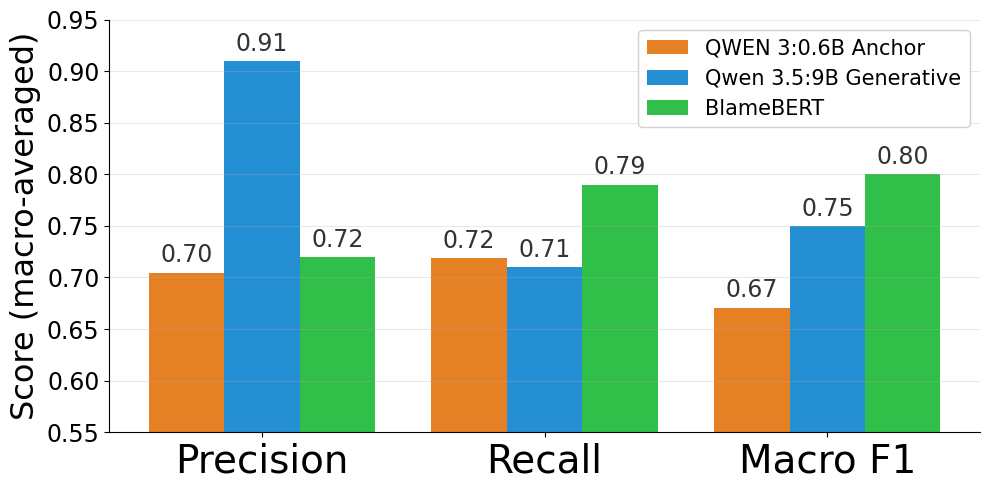

In [11]:
def plot_metric_comparison(df, save_path: Path | None = None):
    metrics = ["precision", "recall", "f1"]
    labels= ["Precision", "Recall", "Macro F1"]
    models = df["model"].tolist()
    n_models = len(models)
    n_metrics = len(metrics)

    x = np.arange(n_metrics)
    width = 0.8 / n_models

    colours = ["#e27005","#0680cd","#13b62e", "#d9190f"]
    fig, ax = plt.subplots(figsize=(10, 5))

    for i, (model, colour) in enumerate(zip(models, colours)):
        row  = df[df["model"] == model].iloc[0]
        values = [row[m] for m in metrics]
        offset = (i - n_models / 2 + 0.5) * width
        bars = ax.bar(x + offset, values, width, label=model, color=colour, alpha=0.88)
        for bar, val in zip(bars, values):
            if not np.isnan(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{val:.2f}",
                    ha="center", va="bottom", fontsize=17, color="#333",
                )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=28)
    ax.tick_params(axis='y', labelsize=17)
    ax.set_ylim(0.55, 0.95)
    ax.set_ylabel("Score (macro-averaged)", fontsize=23)
    #ax.set_title(
    #    "Qwen Embeddings vs. Qwen Generative vs. BlameBERT\n",
    #    fontsize=12, pad=12,)
    #ax.axhline(0.80, color="#2c7bb6", linewidth=1.0, linestyle="--", alpha=0.5, label="BlameBERT F1 reference")
    ax.legend(loc="upper right", fontsize=15, framealpha=0.9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linewidth=0.7)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


plot_metric_comparison(
    df_results[["model","precision","recall","f1"]].dropna(subset=["f1"]),
    save_path=out_dir / "metric_comparison_new_anchors.png",
)

### 6c. Confusion matrices

Saved: out\confusion_matrices.png


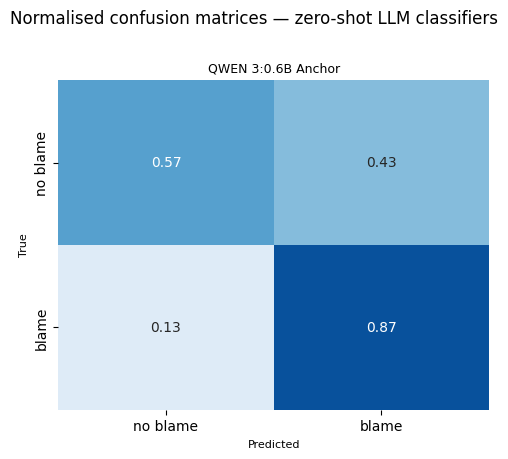

In [12]:
def plot_confusion_matrices(results, save_path: Path | None = None):
    valid = [r for r in results if r.get("_preds") is not None]

    n = len(valid)
    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axes = np.array(axes).flatten()

    for ax, row in zip(axes, valid):
        cm   = confusion_matrix(row["_labels"], row["_preds"], normalize="true")
        sns.heatmap(
            cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["no blame", "blame"],
            yticklabels=["no blame", "blame"],
            ax=ax, cbar=False, vmin=0, vmax=1,
        )
        ax.set_title(row["model"], fontsize=9)
        ax.set_xlabel("Predicted", fontsize=8)
        ax.set_ylabel("True", fontsize=8)

    # Hide any unused subplots
    for ax in axes[len(valid):]:
        ax.set_visible(False)

    fig.suptitle("Normalised confusion matrices — zero-shot LLM classifiers",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()
    
plot_confusion_matrices(
    all_results,
    save_path=out_dir / "confusion_matrices.png",
)

## 8. Save final results table

In [13]:
save_cols = ["model", "precision", "recall", "f1", "f1_blame", "f1_no_blame",
             "accuracy", "mcc", "n_evaluated", "n_failures"]

df_save = df_results[[c for c in save_cols if c in df_results.columns]]
df_save.to_csv(out_dir / "results_summary.csv", index=False)
print("Results saved to results/results_summary.csv")
print()
print(df_save.to_string(index=False))

Results saved to results/results_summary.csv

                 model  precision  recall     f1  f1_blame  f1_no_blame  accuracy    mcc  n_evaluated  n_failures
    QWEN 3:0.6B Anchor     0.7048  0.7184 0.6708    0.6499       0.6918    0.6722 0.4229        424.0         0.0
Qwen 3.5:9B Generative     0.9100  0.7100 0.7500       NaN          NaN    0.8400    NaN          NaN         NaN
             BlameBERT     0.7200  0.7900 0.8000       NaN          NaN    0.8200    NaN        424.0         0.0
